Factor relative performance:
Categorical features

In [59]:
# Import libraries:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import os

In [60]:
import os
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

In [61]:
df_factors = pd.read_csv("factor_returns.csv", parse_dates=['Date'])
df_factors = df_factors.set_index('Date')

In [62]:
# --- Data Upload ---
def load_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    return df

file_path = ('factor_returns.csv')
df=load_data(file_path)

# Ensure data type is: float
print(df.dtypes)

Momentum    float64
Value       float64
Quality     float64
dtype: object


In [63]:
"""
# --- Relative Returns Calculation ---
def relative_returns(df):
    for factor in ['Momentum', 'Value', 'Quality']:
        df[f'{factor}_Relative'] = df[factor] - df['Benchmarks']
    return df

df_rel_returns = relative_returns(df)
print(df_rel_returns)
"""

"\n# --- Relative Returns Calculation ---\ndef relative_returns(df):\n    for factor in ['Momentum', 'Value', 'Quality']:\n        df[f'{factor}_Relative'] = df[factor] - df['Benchmarks']\n    return df\n\ndf_rel_returns = relative_returns(df)\nprint(df_rel_returns)\n"

In [64]:
# --- Relative Performance Between Factors ---
def factor_relative_returns(df, factors=None):

    if factors is None:
        factors = ['Momentum', 'Value', 'Quality']
    
    # Calculate all pairwise relative returns
    for i, factor1 in enumerate(factors):
        for j, factor2 in enumerate(factors):
            if i < j:  # Avoid duplicates and self-comparisons
                rel_col = f'{factor1}_vs_{factor2}'
                df[rel_col] = df[factor1] - df[factor2]
    
    return df

# Usage
df_factor_rel = factor_relative_returns(df.copy())
print(df_factor_rel)

            Momentum     Value   Quality  Momentum_vs_Value  \
Date                                                          
2007-01-01       NaN       NaN  0.000000                NaN   
2007-01-08       NaN  0.013676  0.000000                NaN   
2007-01-15       NaN  0.016786  0.000000                NaN   
2007-01-22  0.000357  0.010732  0.014931          -0.010375   
2007-01-29  0.021934  0.011995 -0.005972           0.009939   
...              ...       ...       ...                ...   
2025-09-08       NaN  0.000000  0.000000                NaN   
2025-09-15       NaN  0.000000  0.000000                NaN   
2025-09-22       NaN  0.000000  0.000000                NaN   
2025-09-29       NaN  0.000000  0.000000                NaN   
2025-10-06       NaN  0.000000  0.000000                NaN   

            Momentum_vs_Quality  Value_vs_Quality  
Date                                               
2007-01-01                  NaN               NaN  
2007-01-08              

In [65]:
# --- Cumulative Relative Returns Calculation ---
factors = ['Momentum_vs_Value', 'Momentum_vs_Quality', 'Value_vs_Quality']
def cumulative_relative_returns(df):
    for factor in factors:
        # Calculate cumulative product of (1 + relative return)
        cumulative_returns = (1 + df[factor]).cumprod() - 1
        df[f'{factor}_Cumulative'] = cumulative_returns
    return df

# Apply the function to your dataframe
df_cumulative = cumulative_relative_returns(df_factor_rel.copy())
print(df_cumulative)

            Momentum     Value   Quality  Momentum_vs_Value  \
Date                                                          
2007-01-01       NaN       NaN  0.000000                NaN   
2007-01-08       NaN  0.013676  0.000000                NaN   
2007-01-15       NaN  0.016786  0.000000                NaN   
2007-01-22  0.000357  0.010732  0.014931          -0.010375   
2007-01-29  0.021934  0.011995 -0.005972           0.009939   
...              ...       ...       ...                ...   
2025-09-08       NaN  0.000000  0.000000                NaN   
2025-09-15       NaN  0.000000  0.000000                NaN   
2025-09-22       NaN  0.000000  0.000000                NaN   
2025-09-29       NaN  0.000000  0.000000                NaN   
2025-10-06       NaN  0.000000  0.000000                NaN   

            Momentum_vs_Quality  Value_vs_Quality  \
Date                                                
2007-01-01                  NaN               NaN   
2007-01-08           

In [66]:
# Trend Scanning Functions
def tval_lin(close):

    # Computes t-values on sample determined by look-forward window L
    x = np.ones((close.shape[0], 2))
    x[:, 1] = np.arange(close.shape[0])
    ols = sm.OLS(close, x).fit()
    return ols.tvalues[1]

def get_bins(molecule, close, span):
    # Pick the value of L that maximizes t-values

    out = pd.DataFrame(index=molecule, columns=['t1', 'tval', 'bin'])
    hrzns = range(*span)
    
    for dt0 in molecule:
        df0 = pd.Series(dtype=float)
        iloc0 = close.index.get_loc(dt0)
        
        if iloc0 + max(hrzns) > len(close):
            continue
            
        for hrzn in hrzns:
            dt1 = close.index[iloc0 + hrzn - 1]
            df1 = close.loc[dt0:dt1]
            df0.loc[dt1] = tval_lin(df1.values)
            
        if not df0.empty:
            dt1 = df0.replace([-np.inf, np.inf, np.nan], 0).abs().idxmax()
            tval = df0[dt1]
            
            # Create binary label based on t-value significance and sign
            if abs(tval) >= 0:
                bin_label = 1 if tval > 0 else 0  # 1=up, 0=down
            else:
                bin_label = np.nan  # Not significant, will be dropped
                
            out.loc[dt0, ['t1', 'tval', 'bin']] = dt1, tval, bin_label


    out['t1'] = pd.to_datetime(out['t1'])
    out['bin'] = pd.to_numeric(out['bin'], downcast='signed')
    return out.dropna(subset=['bin'])

In [67]:
# Execute:
if __name__ == "__main__":
    # Load data
    file_path = 'factor_returns.csv'
    df = load_data(file_path)
    
    # Calculate returns
    df = factor_relative_returns(df)
    df = cumulative_relative_returns(df)
    
    # Apply trend scanning to each factor
    span = (5,11)
    

    factors_to_scan = ['Momentum_vs_Value', 'Value_vs_Quality', 'Momentum_vs_Quality']
    
    for factor in factors_to_scan:
        col_name = f'{factor}_Cumulative'
        if col_name not in df.columns:
            print(f"Warning: Column '{col_name}' not found. Skipping {factor}.")
            continue

        print(f"\nProcessing {factor}...")
        print(f"Data shape: {df[col_name].shape}")
        print(f"NaN values: {df[col_name].isna().sum()}")
        
        # Get trend labels with error handling
        try:
            trend_labels = get_bins(df.index, df[col_name], span)
            
            # Check if trend_labels is None
            if trend_labels is None:
                print(f"Error: get_bins() returned None for {factor}")
                continue
                
            print(f"Trend labels shape: {trend_labels.shape}")
            print(f"Trend labels index type: {type(trend_labels.index)}")
            
            # Ensure proper index alignment
            if not df.index.equals(trend_labels.index):
                print("Index mismatch - reindexing trend labels...")
                trend_labels = trend_labels.reindex(df.index)
            
            # Merge labels back to original DataFrame
            label_col_name = f'{factor}_trend'
            df[label_col_name] = trend_labels['bin']  
            
            print(f"Successfully added trend labels for {factor}")
            print(f"Non-NaN trend values: {df[label_col_name].notna().sum()}")
            
        except Exception as e:
            print(f"Error processing {factor}: {e}")
            import traceback
            traceback.print_exc()
    
    # Save results
    df_factor_ts=df[['Momentum_vs_Value_trend', 'Value_vs_Quality_trend', 'Momentum_vs_Quality_trend']]
    df_factor_ts.to_csv('labeled_relative_factor_returns.csv', index=True)
    print("\nLabeled data saved to 'labeled_relative_factor_returns.csv'")


Processing Momentum_vs_Value...
Data shape: (980,)
NaN values: 95
Trend labels shape: (877, 3)
Trend labels index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index mismatch - reindexing trend labels...
Successfully added trend labels for Momentum_vs_Value
Non-NaN trend values: 877

Processing Value_vs_Quality...
Data shape: (980,)
NaN values: 5
Trend labels shape: (962, 3)
Trend labels index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index mismatch - reindexing trend labels...
Successfully added trend labels for Value_vs_Quality
Non-NaN trend values: 962

Processing Momentum_vs_Quality...
Data shape: (980,)
NaN values: 91
Trend labels shape: (885, 3)
Trend labels index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index mismatch - reindexing trend labels...
Successfully added trend labels for Momentum_vs_Quality
Non-NaN trend values: 885

Labeled data saved to 'labeled_relative_factor_returns.csv'


In [68]:
print(df.columns)

Index(['Momentum', 'Value', 'Quality', 'Momentum_vs_Value',
       'Momentum_vs_Quality', 'Value_vs_Quality',
       'Momentum_vs_Value_Cumulative', 'Momentum_vs_Quality_Cumulative',
       'Value_vs_Quality_Cumulative', 'Momentum_vs_Value_trend',
       'Value_vs_Quality_trend', 'Momentum_vs_Quality_trend'],
      dtype='object')


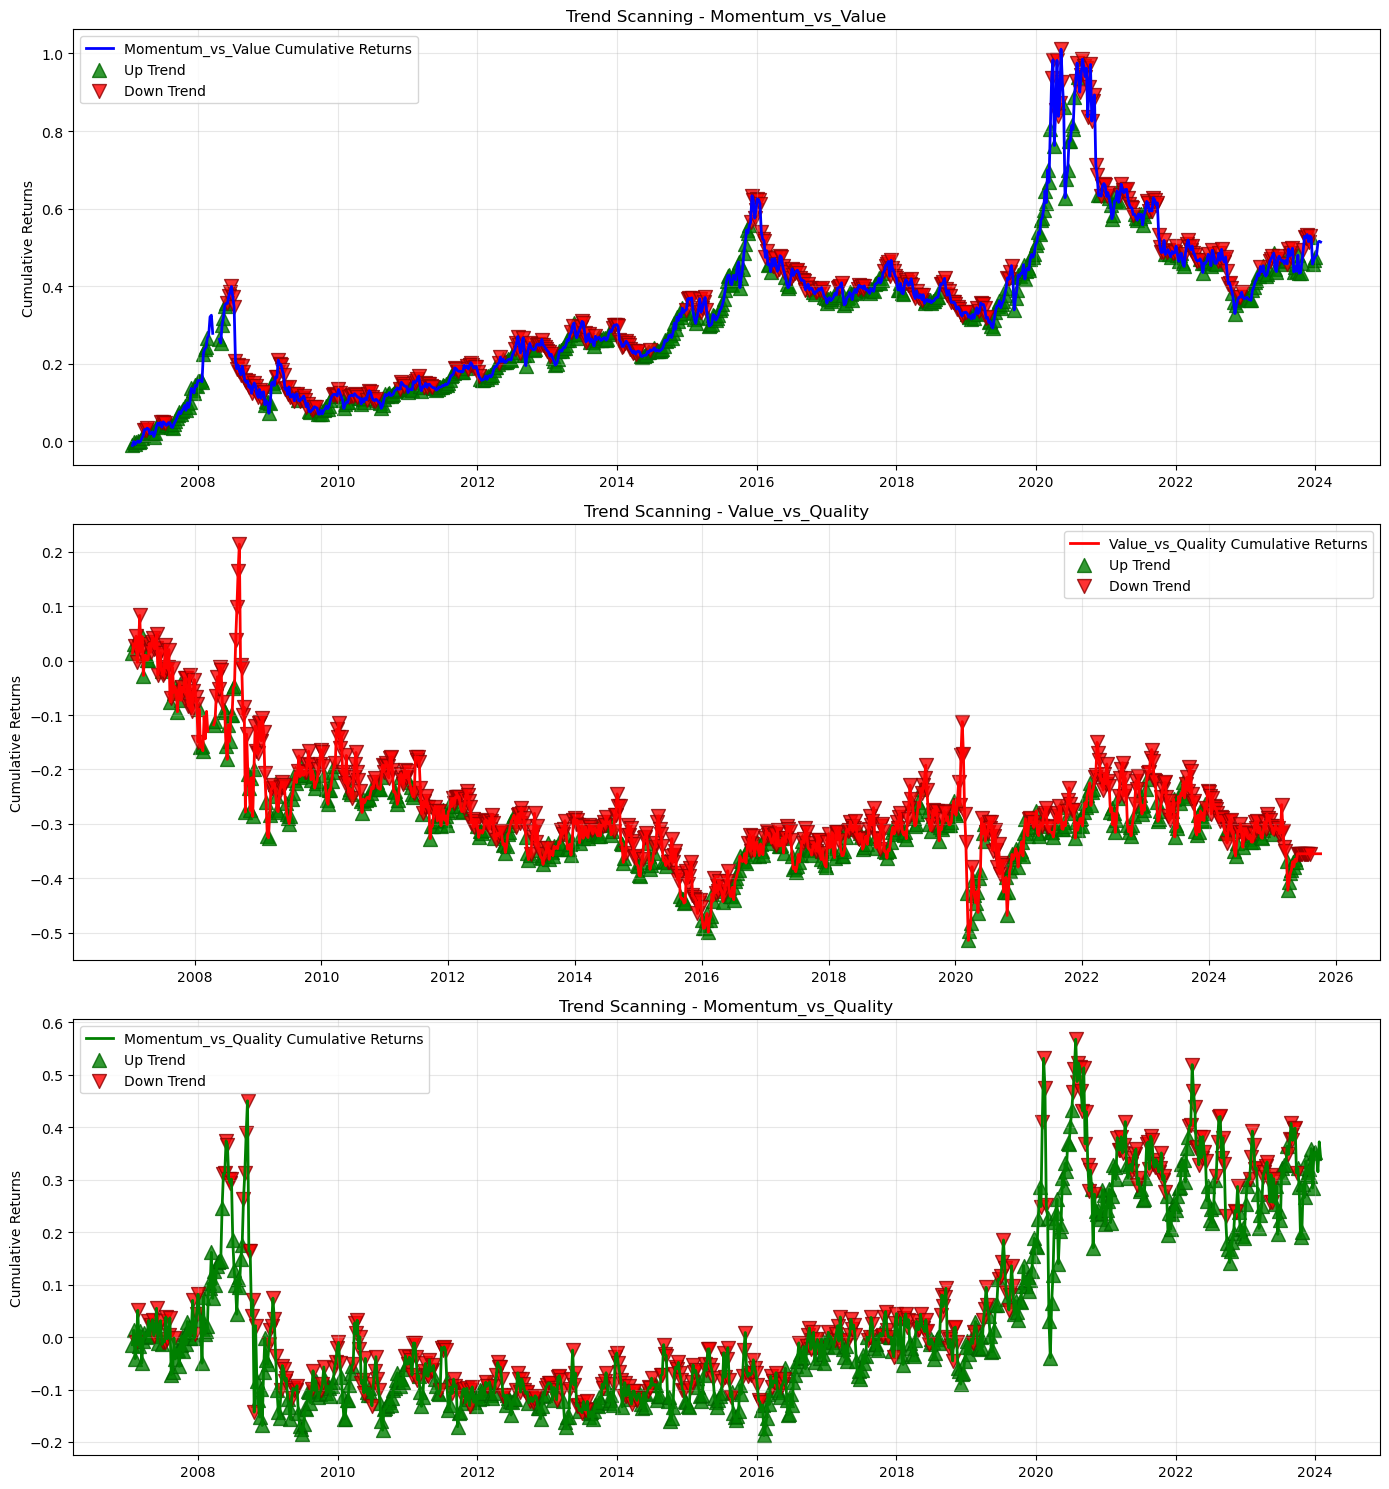

In [69]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_trend_triangles(df, factors):
    """
    Plot cumulative returns with triangle markers for trend signals for multiple factors
    """
    # Create subplots for each factor
    n_factors = len(factors)
    fig, axes = plt.subplots(n_factors, 1, figsize=(14, 5 * n_factors))
    
    # If only one factor, make axes a list for consistent indexing
    if n_factors == 1:
        axes = [axes]
    
    # Colors for different factors
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    for i, factor in enumerate(factors):
        cum_col = f'{factor}_Cumulative'
        trend_col = f'{factor}_trend'
        
        if cum_col not in df.columns or trend_col not in df.columns:
            print(f"Warning: Columns for {factor} not found. Skipping.")
            continue
        
        ax = axes[i]
        
        # Plot cumulative returns
        ax.plot(df.index, df[cum_col], color=colors[i % len(colors)], 
                linewidth=2, label=f'{factor} Cumulative Returns')
        
        # Add trend signals as triangles
        valid_trends = df[trend_col].dropna()
        
        # Up trends (green upward triangles)
        up_trends = valid_trends[valid_trends == 1]
        if not up_trends.empty:
            ax.scatter(up_trends.index, df.loc[up_trends.index, cum_col], 
                      color='green', marker='^', s=100, label='Up Trend', alpha=0.8,
                      edgecolors='darkgreen', linewidth=1)
        
        # Down trends (red downward triangles)
        down_trends = valid_trends[valid_trends == 0]
        if not down_trends.empty:
            ax.scatter(down_trends.index, df.loc[down_trends.index, cum_col], 
                      color='red', marker='v', s=100, label='Down Trend', alpha=0.8,
                      edgecolors='darkred', linewidth=1)
        
        ax.set_title(f'Trend Scanning - {factor}')
        ax.set_ylabel('Cumulative Returns')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# Execute, load data and plot:

if __name__ == "__main__":
    # Load data
    # df = pd.read_csv('labeled_relative_factor_returns.csv', index_col=0, parse_dates=True)
    
    # Factors to plot
    factors_to_plot = ['Momentum_vs_Value', 'Value_vs_Quality', 'Momentum_vs_Quality']
    
    # Plot
    plot_trend_triangles(df, factors_to_plot)